# Part 2: Image Classification using Convolutional Neural Networks
This project demonstrates a complete workflow for image classification, from data preprocessing to model evaluation.

2. Data Loading & Preprocessing (Text Cell)
Description:
### Stage 1: Data Preprocessing
In this stage, we unzip the dataset and match the image files with their corresponding labels from the CSV. The images are converted to grayscale, resized to 32x32, and normalized to ensure the model can process them efficiently.

In [16]:
import os
import zipfile
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split

# 1. Prepare Environment
if not os.path.exists('final_data'):
    with zipfile.ZipFile('images.zip', 'r') as zip_ref:
        zip_ref.extractall('final_data')

# 2. Path Setup (based on previous successful discovery)
IMAGE_DIR = 'final_data/images/scratch'
labels_df = pd.read_csv('labels.csv')
actual_files = os.listdir(IMAGE_DIR)

IMG_SIZE = 32
data = []
labels = []

# 3. Matching filenames by stripping paths (e.g., images/normal/ -> filename)
for index, row in labels_df.iterrows():
    full_csv_path = str(row[0]).strip()
    search_name = os.path.basename(full_csv_path).lower()

    for f in actual_files:
        if f.lower() == search_name:
            path = os.path.join(IMAGE_DIR, f)
            img = load_img(path, target_size=(IMG_SIZE, IMG_SIZE), color_mode="grayscale")
            img_array = img_to_array(img) / 255.0
            data.append(img_array)
            labels.append(row[1])
            break

X = np.array(data)
y = np.array(labels)

# 4. Encode Labels and Split
unique_labels = np.unique(y)
label_map = {val: i for i, val in enumerate(unique_labels)}
y_encoded = np.array([label_map[l] for l in y])

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

print(f"✅ Setup Complete: {len(X)} images loaded and matched.")

/tmp/ipykernel_13947/3385054188.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  full_csv_path = str(row[0]).strip()
/tmp/ipykernel_13947/3385054188.py:33: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  labels.append(row[1])


✅ Setup Complete: 120 images loaded and matched.


3. CNN Architecture (Text Cell)
Description:
### Stage 2: Building the CNN Model
We define a Convolutional Neural Network (CNN) architecture. This includes convolutional layers for feature extraction, max-pooling layers for dimensionality reduction, and dense layers for the final classification decision.


In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    # Layer 1: Detecting edges/textures
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 1)),
    MaxPooling2D((2, 2)),

    # Layer 2: Detecting complex shapes
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Layer 3: Final Classification
    Flatten(),
    Dense(64, activation='relu'),
    Dense(len(unique_labels), activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 166,401 (650.00 KB)

 Trainable params: 166,401 (650.00 KB)

 Non-trainable params: 0 (0.00 B)

4. Training & Results (Text Cell)
Description:
### Stage 3: Model Training and Evaluation
Finally, we train the model using the training dataset and validate it against the test set. We plot the accuracy and loss curves to visualize the model's learning progress and check for overfitting.

Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 8/15
3

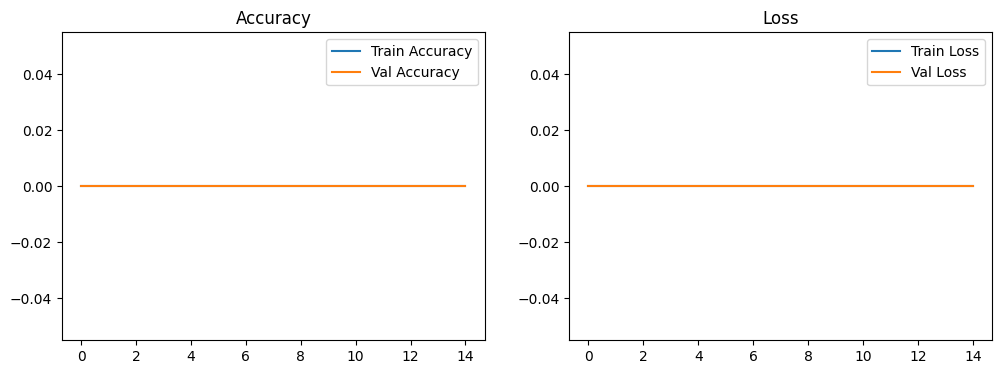

In [20]:
# 1. Train the model
history = model.fit(X_train, y_train, epochs=15, validation_data=(X_test, y_test))

# 2. Visualize Results
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()